# Task 3: Heart Disease Prediction

**Intern:** Hafsa Atif

**Internship:** DevelopersHub Corporation — AI/ML Engineering Internship

**Objective:** Build a binary classifier that predicts whether a patient
has heart disease, using the UCI Heart Disease dataset (303 patients, 13
features + target). Includes a full EDA pass — distributions, class
balance, correlations, and feature-vs-target comparisons — before
modeling. Dataset loads directly from a public URL — no Kaggle download
needed.

### Import Libraries

In [1]:
# pandas/numpy for data handling
import pandas as pd
import numpy as np
# matplotlib/seaborn for charts
import matplotlib.pyplot as plt
import seaborn as sns

# train/test split utility
from sklearn.model_selection import train_test_split
# the classification model we'll train
from sklearn.linear_model import LogisticRegression
# scaler needed because Logistic Regression is sensitive to feature scale
from sklearn.preprocessing import StandardScaler
# evaluation metrics
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

sns.set_style("whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


### Load the Dataset

In [2]:
# direct CSV URL — no manual Kaggle download required
url = 'https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv'

# pandas can read a CSV straight from a URL
df = pd.read_csv(url)

# confirm shape: should be 303 rows, 14 columns (13 features + target)
print('Shape:', df.shape)
df.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### Check Data Types & Structure

In [3]:
# check column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


### Check Missing Values

In [4]:
# count missing values per column (should be zero for this dataset)
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


### Target Class Balance

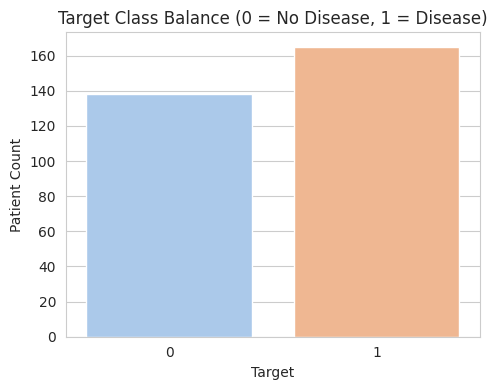

target
1    165
0    138
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(5, 4))

# visual version of the target counts: 1 = disease, 0 = no disease
sns.countplot(data=df, x='target', hue='target', palette='pastel', legend=False)

plt.title('Target Class Balance (0 = No Disease, 1 = Disease)')
plt.xlabel('Target')
plt.ylabel('Patient Count')
plt.tight_layout()
plt.show()

# exact counts behind the chart above
print(df['target'].value_counts())

### Age & Cholesterol Distribution

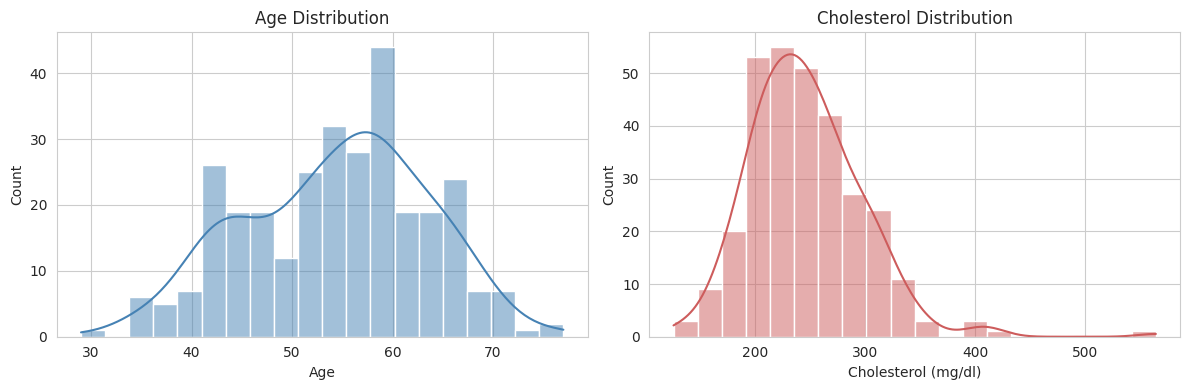

In [6]:
# set up two histograms side by side: age and cholesterol
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# age distribution
sns.histplot(df['age'], bins=20, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

# cholesterol distribution
sns.histplot(df['chol'], bins=20, kde=True, color='indianred', ax=axes[1])
axes[1].set_title('Cholesterol Distribution')
axes[1].set_xlabel('Cholesterol (mg/dl)')

plt.tight_layout()
plt.show()

### Correlation Heatmap

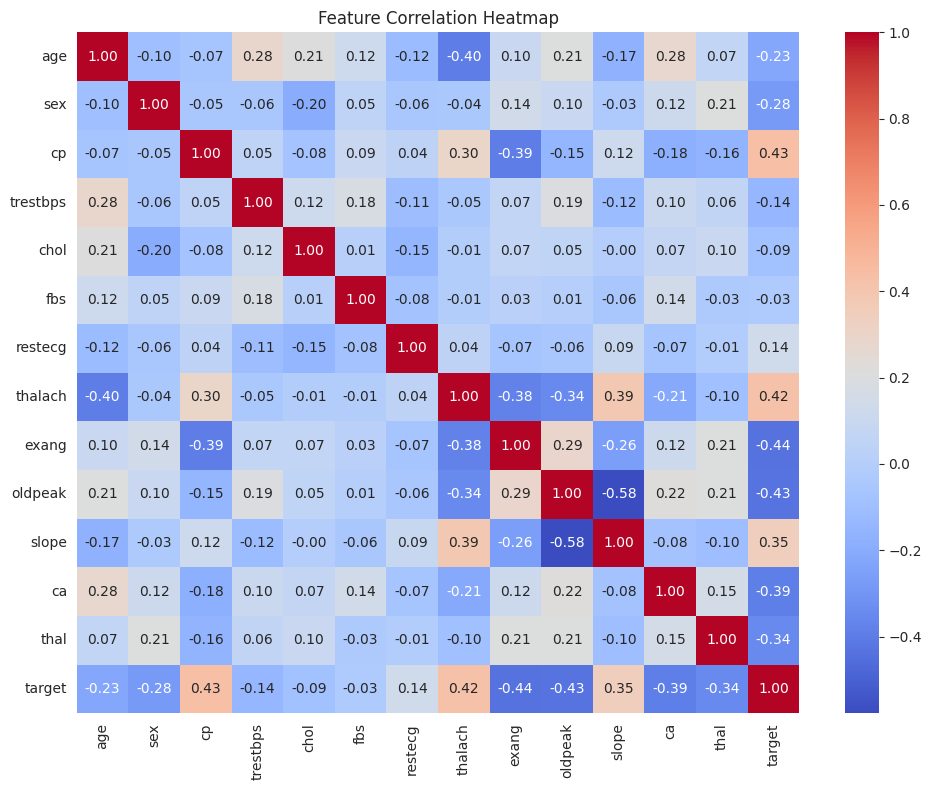

In [7]:
plt.figure(figsize=(10, 8))

# correlation matrix heatmap — shows how every feature relates to every other
sns.heatmap(
    df.corr(),       # compute pairwise correlation
    annot=True,      # print the correlation number in each cell
    fmt='.2f',       # round to 2 decimal places
    cmap='coolwarm'  # red = positive correlation, blue = negative
)

plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### Chest Pain Type vs Target & Age vs Target

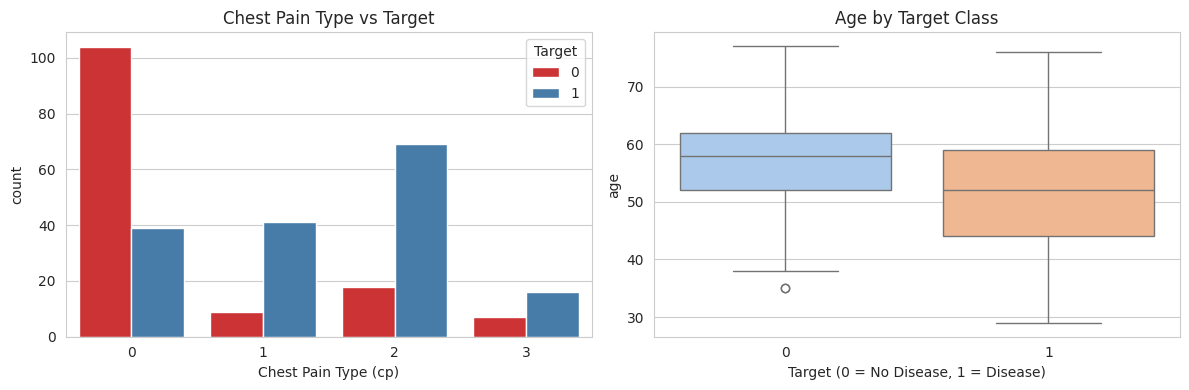

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# how chest pain type (cp) breaks down across the two target classes
sns.countplot(data=df, x='cp', hue='target', palette='Set1', ax=axes[0])
axes[0].set_title('Chest Pain Type vs Target')
axes[0].set_xlabel('Chest Pain Type (cp)')
axes[0].legend(title='Target')

# how age compares between patients with and without disease
sns.boxplot(data=df, x='target', y='age', hue='target', palette='pastel', ax=axes[1], legend=False)
axes[1].set_title('Age by Target Class')
axes[1].set_xlabel('Target (0 = No Disease, 1 = Disease)')

plt.tight_layout()
plt.show()

### Train-Test Split & Feature Scaling

In [9]:
# X = all columns except target (the features)
X = df.drop('target', axis=1)
# y = the column we want to predict
y = df['target']

# 80% of data for training, 20% held out for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42   # random_state makes the split reproducible
)

# fit the scaler on training data only, then apply to both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # learn mean/std + transform
X_test_scaled = scaler.transform(X_test)        # reuse the same mean/std

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 242
Testing samples: 61


### Train the Model & Check Accuracy

In [10]:
# create the Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
# train it on the scaled training data
model.fit(X_train_scaled, y_train)

# predict the class (0 or 1) for the test set
y_pred = model.predict(X_test_scaled)
# predict the probability of class 1 (needed for the ROC curve later)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# accuracy = % of test samples predicted correctly
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc * 100:.2f}%')
print()
# precision/recall/F1 per class
print(classification_report(y_test, y_pred))

Accuracy: 85.25%

              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



### Confusion Matrix

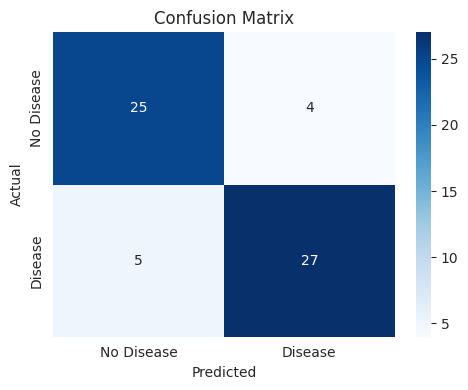

In [11]:
# build the confusion matrix: rows = actual, columns = predicted
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease']
)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### ROC Curve

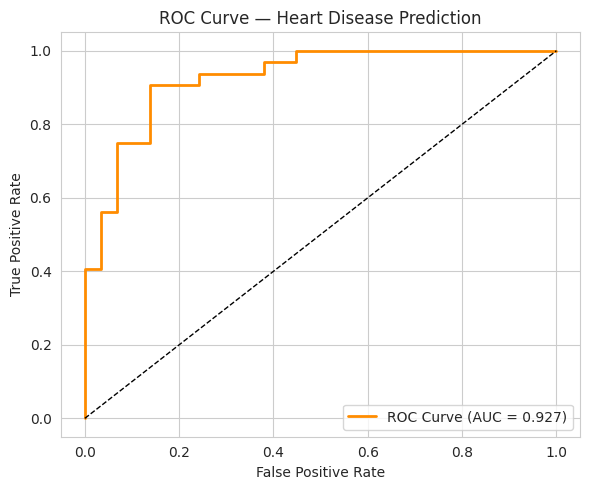

In [12]:
# compute false positive rate, true positive rate at every threshold
fpr, tpr, _ = roc_curve(y_test, y_prob)
# area under the ROC curve — 0.5 = random guessing, 1.0 = perfect
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)   # diagonal reference line = random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Heart Disease Prediction')
plt.legend()
plt.tight_layout()
plt.show()

## Summary & Insights

- **Objective:** Predict heart disease risk from 13 patient health features.
- **Dataset:** UCI Heart Disease dataset (303 patients), loaded directly
  from a public URL — no manual download required.
- **Cleaning:** No missing values found anywhere in the dataset.
- **Class balance:** Target classes are reasonably balanced (~54% disease
  vs ~46% no disease), so accuracy is a fair metric here, backed up by AUC.
- **Distributions:** Most patients are between roughly 45–65 years old.
  Cholesterol is right-skewed, with most patients clustering between
  ~200–280 mg/dl and a handful of high outliers.
- **Correlation heatmap:** `cp` (chest pain type) and `thalach` (max heart
  rate) are positively associated with the target, while `exang`
  (exercise-induced angina) and `oldpeak` are negatively associated —
  consistent with clinical expectations.
- **Chest pain vs target:** Certain chest pain types are noticeably more
  common among patients with disease, confirming `cp` as a strong signal.
- **Age vs target:** The age spread is fairly similar between the two
  classes, suggesting age alone isn't a strong differentiator without
  combining it with other features.
- **Model:** Logistic Regression with standardized features.
- **Results:** Accuracy, confusion matrix, and AUC are printed/plotted
  above — copy your actual run numbers into the README.
- **Key finding:** Chest pain type and max heart rate achieved are among
  the strongest predictors of heart disease in this dataset.